# Counter-Attacks: Building the Trajectory Dataset

**Analytics Cup 2.0 — Football, Defensive Positioning**

The strongest signal in this project so far (Notebook 5 follow-up) is that high-line teams press
*specifically in the instant after losing the ball* (ρ=0.945 between defensive line height and
share of `counter_press` engagements). The moment that pressing exists to prevent is the rival
counter-attack — which is also, by far, the most dangerous phase type in the dataset.

This notebook builds the raw material for studying **how teams defend counter-attacks**: every
phase where the *attacking* team's phase type is `transition` or `quick_break`, with the
frame-by-frame position of all 22 players and the ball. Nothing is modelled yet — the goal is a
verified, reproducible dataset and a visual understanding of what these sequences look like before
deciding what a "best defensive route" should even mean.


## 1. Build (or load) the dataset

Extraction logic lives in [`src/counter_attacks.py`](../src/counter_attacks.py). The result is cached under `data/processed/` — it is derived SkillCorner data, so it's gitignored and regenerated from the raw files on a clean checkout (~100 s).

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

from counter_attacks import load_or_build_counterattacks

pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "../../skillcorner-opendata/data/matches"
CACHE_DIR = "../data/processed"
FPS = 10

counters, traj = load_or_build_counterattacks(DATA_DIR, CACHE_DIR)
print(f"counter-attack phases: {len(counters)}")
print(f"trajectory rows:       {len(traj):,}")
traj.head()


counter-attack phases: 296
trajectory rows:       744,510


,match_id,phase_id,frame,player_id,team_id,role,x,y
0,1874553,35,2982,50999.0,1802.0,defender,46.76,0.34
1,1874553,35,2982,69111.0,1802.0,defender,38.42,13.87
2,1874553,35,2982,51050.0,1802.0,defender,34.66,-8.32
3,1874553,35,2982,560983.0,1802.0,defender,27.03,21.06
4,1874553,35,2982,50994.0,1802.0,defender,28.24,-19.92


In [2]:
outcomes = counters.groupby("team_in_possession_phase_type").agg(
    n=("phase_id", "size"),
    shot_rate=("team_possession_lead_to_shot", "mean"),
    goal_rate=("team_possession_lead_to_goal", "mean"),
    mean_duration_s=("duration", "mean"),
)
print(f"Total shots: {int(counters['team_possession_lead_to_shot'].sum())} | total goals: {int(counters['team_possession_lead_to_goal'].sum())}")
outcomes.round(3)


Total shots: 97 | total goals: 15


,n,shot_rate,goal_rate,mean_duration_s
team_in_possession_phase_type,,,,
quick_break,111,0.450,0.045,9.076
transition,185,0.254,0.054,11.978


## 2. Sanity checks — including a coordinate trap

**Raw tracking is not attack-normalised.** `dynamic_events` x/y are (Notebook 5 found the attacked
goal is always at x=+52.5 there), but the raw tracking files use fixed pitch coordinates: before
normalising, counters that end in a shot finished with the ball near x=+48 for `left_to_right`
phases and x=−47 for `right_to_left` ones. `normalize_attack_direction` rotates the
`right_to_left` phases 180° (x→−x, y→−y — a rotation, not a mirror, so each wing stays the
attacker's same wing). After normalising, both directions should end near +x:

In [3]:
ball = traj[traj["role"] == "ball"].sort_values("frame")
ball_end = ball.groupby(["match_id", "phase_id"]).tail(1)[["match_id", "phase_id", "x"]].rename(columns={"x": "ball_x_end"})
check = counters.merge(ball_end, on=["match_id", "phase_id"])
check[check["team_possession_lead_to_shot"]].groupby("attacking_side")["ball_x_end"].mean().round(1)


attacking_side
left_to_right    48.4
right_to_left    47.4
Name: ball_x_end, dtype: float64

In [4]:
start = traj.merge(counters[["match_id", "phase_id", "frame_start"]], on=["match_id", "phase_id"])
start = start[start["frame"] == start["frame_start"]]
players_at_start = start[start["role"] != "ball"].groupby(["match_id", "phase_id"]).size()
print("players tracked at the first frame of each counter:", players_at_start.describe()[["min", "50%", "max"]].to_dict())
print("counters with ball position at the first frame:", start[start["role"] == "ball"][["match_id", "phase_id"]].drop_duplicates().shape[0], "/", len(counters))

# Physical plausibility: player speeds from consecutive 10 fps frames should stay under ~11 m/s
p = traj[traj["role"] != "ball"].sort_values(["match_id", "phase_id", "player_id", "frame"])
g = p.groupby(["match_id", "phase_id", "player_id"])
step = np.hypot(g["x"].diff(), g["y"].diff())
consecutive = g["frame"].diff() == 1
speed = (step[consecutive] * FPS)
print(f"player speed (m/s): median={speed.median():.2f}, p99={speed.quantile(0.99):.2f}, p99.9={speed.quantile(0.999):.2f}, max={speed.max():.2f}")


players tracked at the first frame of each counter: {'min': 22.0, '50%': 22.0, 'max': 22.0}
counters with ball position at the first frame: 296 / 296


player speed (m/s): median=2.95, p99=7.91, p99.9=9.07, max=26.13


In [5]:
print(f"player-frames faster than 12 m/s (beyond any human sprint): {(speed > 12).sum()} of {len(speed):,} ({(speed > 12).mean():.4%})")


player-frames faster than 12 m/s (beyond any human sprint): 89 of 705,606 (0.0126%)


All 22 players and the ball are present at the start of every counter, and the bulk of the speed
distribution is physically plausible (median ~3 m/s, 99.9th percentile ~9 m/s). The **maximum is
not** (~26 m/s — no human runs that fast): tracking is broadcast-based and partly *extrapolated*
for off-camera players, and a tiny fraction of frames (under 0.02%) jump. Irrelevant for positions,
but any model that uses **velocities** must smooth or clip them rather than trust single-frame
differences.

## 3. The situation at the moment the counter starts

Two things a coach would describe first: **where** the ball was won, and **the numbers** —
how many defenders are already goal-side of the ball vs. how many attackers are ahead of it.

In [6]:
first = traj.merge(counters[["match_id", "phase_id", "frame_start"]], on=["match_id", "phase_id"])
first = first[first["frame"] == first["frame_start"]]
ball0 = first[first["role"] == "ball"][["match_id", "phase_id", "x", "y"]].rename(columns={"x": "bx", "y": "by"})
p0 = first[first["role"] != "ball"].merge(ball0, on=["match_id", "phase_id"])

situation = p0.groupby(["match_id", "phase_id"]).apply(lambda g: pd.Series({
    "attackers_ahead_of_ball": int(((g["role"] == "attacker") & (g["x"] > g["bx"])).sum()),
    "defenders_goalside_of_ball": int(((g["role"] == "defender") & (g["x"] > g["bx"])).sum()),
    "ball_x_start": g["bx"].iloc[0],
}), include_groups=False).reset_index()
situation[["attackers_ahead_of_ball", "defenders_goalside_of_ball"]] = situation[["attackers_ahead_of_ball", "defenders_goalside_of_ball"]].astype(int)
situation["numerical_balance"] = situation["defenders_goalside_of_ball"] - situation["attackers_ahead_of_ball"]
situation["start_zone"] = pd.cut(situation["ball_x_start"], [-60, -17.5, 17.5, 60], labels=["attacker's own third", "middle third", "final third"])

counters_s = counters.merge(situation, on=["match_id", "phase_id"])
counters_s.groupby("start_zone", observed=True).agg(
    n=("phase_id", "size"),
    shot_rate=("team_possession_lead_to_shot", "mean"),
    goal_rate=("team_possession_lead_to_goal", "mean"),
).round(3)


,n,shot_rate,goal_rate
start_zone,,,
attacker's own third,123,0.211,0.057
middle third,136,0.346,0.044
final third,37,0.649,0.054


In [7]:
counters_s["balance_bin"] = pd.cut(counters_s["numerical_balance"], [-20, 2, 4, 20], labels=["<=2", "3-4", "5+"])
print(counters_s["numerical_balance"].describe().round(2).to_dict())
counters_s.groupby("balance_bin", observed=True).agg(
    n=("phase_id", "size"),
    shot_rate=("team_possession_lead_to_shot", "mean"),
    goal_rate=("team_possession_lead_to_goal", "mean"),
).round(3)


{'count': 296.0, 'mean': 2.58, 'std': 1.14, 'min': 0.0, '25%': 2.0, '50%': 3.0, '75%': 3.0, 'max': 6.0}


,n,shot_rate,goal_rate
balance_bin,,,
<=2,147,0.293,0.054
3-4,133,0.376,0.045
5+,16,0.250,0.062


**Where** the ball is won matters a lot (a counter starting in the final third ends in a shot
roughly three times as often as one starting in the attacker's own third). **The numbers at the
instant of the turnover, on their own, don't** — almost every counter starts with the defending
team holding a goal-side majority (median +3), and shot rate doesn't move cleanly with it. That's
a first hint that what separates a dangerous counter from a harmless one is not the snapshot at
the turnover, but **what happens in the next few seconds** — which is exactly the part defenders
control.

## 4. What these sequences look like

Two real counters that both started in the middle third: one ended in a goal, one was stopped (possession lost, no shot). Hollow markers = positions at the turnover, filled = at the end of the phase; red = attackers, blue = defenders, black dashed = ball. Attack always goes left → right.

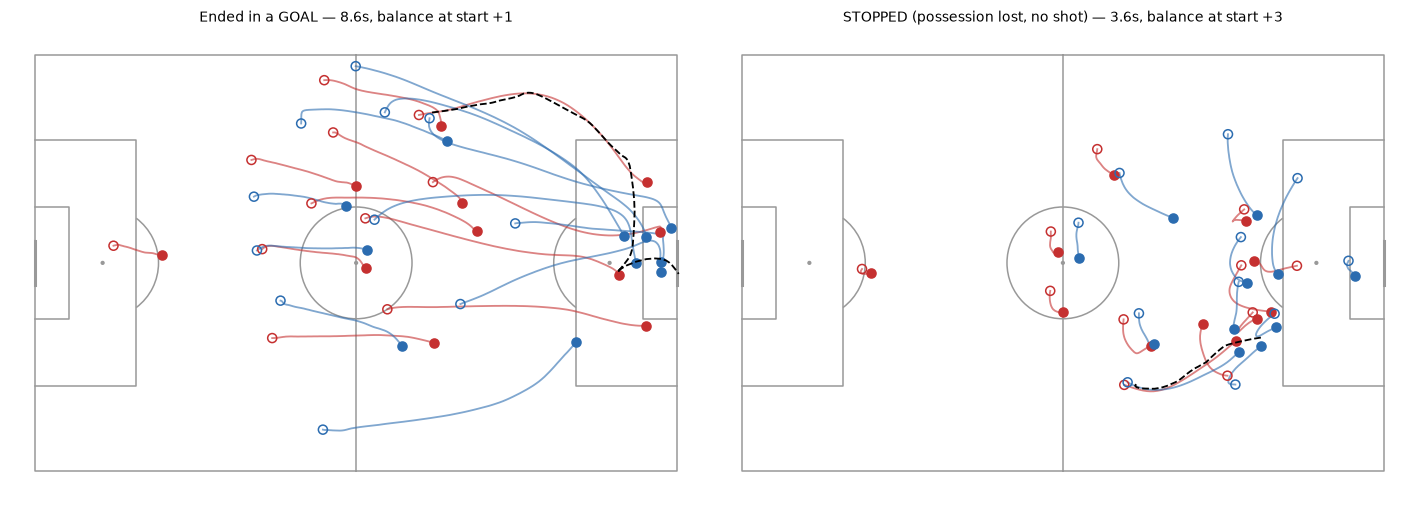

In [8]:
def plot_counter(ax, match_id, phase_id, title):
    pitch = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68, line_color="#999999", linewidth=1)
    pitch.draw(ax=ax)
    t = traj[(traj["match_id"] == match_id) & (traj["phase_id"] == phase_id)].sort_values("frame")
    for (role, pid), g in t.groupby(["role", "player_id"], dropna=False):
        if role == "ball":
            continue
        color = "#c53030" if role == "attacker" else "#2b6cb0"
        ax.plot(g["x"], g["y"], color=color, alpha=0.6, linewidth=1.2)
        ax.scatter(g["x"].iloc[0], g["y"].iloc[0], s=35, facecolors="none", edgecolors=color, zorder=3)
        ax.scatter(g["x"].iloc[-1], g["y"].iloc[-1], s=35, color=color, zorder=3)
    b = t[t["role"] == "ball"]
    ax.plot(b["x"], b["y"], "k--", linewidth=1.2, zorder=4)
    ax.set_title(title, fontsize=9)

mid_zone = counters_s[counters_s["start_zone"] == "middle third"].sort_values(["match_id", "phase_id"])
goal_ex = mid_zone[mid_zone["team_possession_lead_to_goal"]].iloc[0]
stop_ex = mid_zone[mid_zone["team_possession_loss_in_phase"] & ~mid_zone["team_possession_lead_to_shot"]].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
plot_counter(axes[0], goal_ex["match_id"], goal_ex["phase_id"], f"Ended in a GOAL — {goal_ex['duration']:.1f}s, balance at start {goal_ex['numerical_balance']:+d}")
plot_counter(axes[1], stop_ex["match_id"], stop_ex["phase_id"], f"STOPPED (possession lost, no shot) — {stop_ex['duration']:.1f}s, balance at start {stop_ex['numerical_balance']:+d}")
plt.tight_layout()
plt.show()


### Every goal vs. an equal number of stopped counters — ball routes only

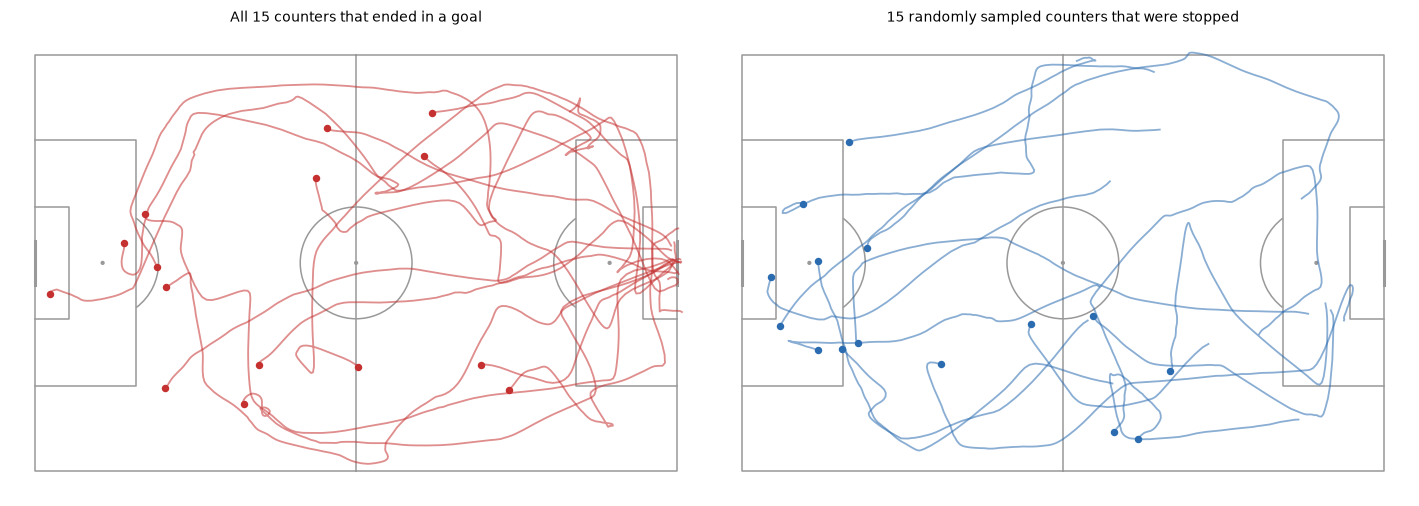

In [9]:
goals = counters_s[counters_s["team_possession_lead_to_goal"]]
stopped = counters_s[counters_s["team_possession_loss_in_phase"] & ~counters_s["team_possession_lead_to_shot"]].sample(len(goals), random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, subset, title, color in [
    (axes[0], goals, f"All {len(goals)} counters that ended in a goal", "#c53030"),
    (axes[1], stopped, f"{len(goals)} randomly sampled counters that were stopped", "#2b6cb0"),
]:
    Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68, line_color="#999999", linewidth=1).draw(ax=ax)
    for _, row in subset.iterrows():
        b = traj[(traj["match_id"] == row["match_id"]) & (traj["phase_id"] == row["phase_id"]) & (traj["role"] == "ball")].sort_values("frame")
        ax.plot(b["x"], b["y"], color=color, alpha=0.55, linewidth=1.2)
        ax.scatter(b["x"].iloc[0], b["y"].iloc[0], s=15, color=color, zorder=3)
    ax.set_title(title, fontsize=9)
plt.tight_layout()
plt.show()


## 5. What this means for the "best defensive route" tool

1. **The dataset is solid**: 296 counters, all 22 players + ball at every start frame, physically
   plausible speeds, and a coordinate trap (raw tracking isn't attack-normalised) caught and fixed
   before it could corrupt anything downstream. The phase window also contains the outcome: in 14 of
   the 15 goal counters the ball ends the phase inside the goal (x≈51–53); the remaining one ends at
   x≈35 and the goal comes in the very next phase (`finish`) of the same possession.
2. **Goals are far too rare to learn routes from**: 15 goals in 296 counters. A map of "which route
   ended in a goal", split by pitch sector × numerical situation, would be built on one or two goals
   per cell — noise dressed up as a recommendation. Shots (97) are better but still thin for that.
3. **The turnover snapshot isn't what decides the outcome** — start zone matters, but the numbers
   at the instant of the loss barely do. The decisive part is the defenders' movement in the next
   seconds, which is precisely what a positioning tool should evaluate.

The design for the next step therefore can't be "count which routes led to goals". It needs an
objective that can be evaluated **at every frame** of every counter — not only 15 times — and then
checked against real outcomes (shots/goals) to prove it measures real danger. That design is
proposed in the conversation before being built.
